## Build a Support Ticket Classifier using Pre-Trained Language Models from HuggingFace

This notebook comprises of an end-to-end text classification pipeline to automatically classify customer support tickets into routing labels using a pre-trained transformer model from Hugging Face.

It includes dataset loading, preprocessing, label preparation, fine-tuning, evaluation, visualizations, and inference on new tickets.

In [1]:
# Installs all required libraries for dataset handling, transformers training, evaluation metrics,and visualizations.

!pip -q install datasets transformers accelerate evaluate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


##Imports, random seed, and device setup

We import the required libraries and set a seed for reproducibility.

In [2]:
# Importing required libraries and setting seeds for reproducible results.

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Load the Customer Support Tickets dataset
We load the dataset from Hugging Face using datasets.load_dataset.
The dataset contains ticket text fields like subject and body, and the routing label queue.

In [3]:
# Loading the dataset from Hugging Face and printing basic structure.

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})

## Inspect columns and sample rows (EDA)
We check the available columns and view a few examples.

In [4]:
# Inspecting dataset columns and showing a few rows for understanding the data.

print("Splits:", dataset.keys())
print("Columns:", dataset["train"].column_names)

df_preview = pd.DataFrame(dataset["train"].select(range(5)))
df_preview

Splits: dict_keys(['train'])
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,None,None,None,None


## Create Model Input Text
Combine subject + body into a single text field
Transformers typically expect one text input. We create text = subject + body.

In [5]:
# Creating a unified 'text' feature from subject and body for classification.

def build_text(example):
    subject = example.get("subject", "") or ""
    body = example.get("body", "") or ""
    example["text"] = subject.strip() + "\n\n" + body.strip()
    return example

dataset = dataset.map(build_text)
dataset["train"][0]["text"][:400]

Map:   0%|          | 0/61765 [00:00<?, ? examples/s]

'Wesentlicher Sicherheitsvorfall\n\nSehr geehrtes Support-Team,\\n\\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberatt'

## Label Selection Strategy (Top-K Queues)

This dataset can have many unique queue labels. Training on all labels may be slow and imbalanced.
So we filter to the Top-K most frequent queues (default K=10). The value of K can be increased if needed.

In [6]:
# Analyzing label distribution and filtering the dataset to the top-K most common queues.

label_col = "queue"
top_k = 10  # change to 15/20 if you want more classes

train_df = pd.DataFrame(dataset["train"])
label_counts = train_df[label_col].value_counts()

top_labels = label_counts.head(top_k).index.tolist()
print("Top labels:", top_labels)

def keep_top_labels(example):
    return example[label_col] in top_labels

filtered = DatasetDict({
    "train": dataset["train"].filter(keep_top_labels),
})

filtered

Top labels: ['Technical Support', 'Product Support', 'Customer Service', 'IT Support', 'Billing and Payments', 'Returns and Exchanges', 'Service Outages and Maintenance', 'Sales and Pre-Sales', 'Human Resources', 'General Inquiry']


Filter:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text'],
        num_rows: 48587
    })
})

## Label Distribution Visualization
Visualize class imbalance
This plot shows the distribution of labels in the filtered dataset.

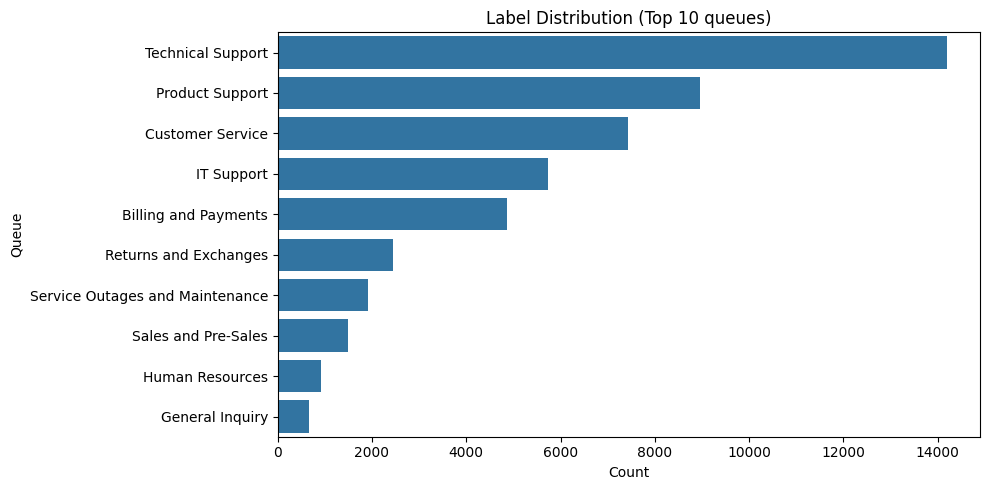

In [7]:
# Visualizing the label distribution for the chosen top-K classes.

filtered_train_df = pd.DataFrame(filtered["train"])
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_train_df, y=label_col, order=filtered_train_df[label_col].value_counts().index)
plt.title(f"Label Distribution (Top {top_k} queues)")
plt.xlabel("Count")
plt.ylabel("Queue")
plt.tight_layout()
plt.show()

In [8]:
# Printing class counts for the selected top-K queues.

class_counts = filtered_train_df[label_col].value_counts().reset_index()
class_counts.columns = ["queue", "count"]
class_counts

,queue,count
0,Technical Support,14186
1,Product Support,8960
2,Customer Service,7420
3,IT Support,5725
4,Billing and Payments,4874
5,Returns and Exchanges,2438
6,Service Outages and Maintenance,1912
7,Sales and Pre-Sales,1490
8,Human Resources,914
9,General Inquiry,668


## Train/Validation/Test Split
Splitting data into train/val/test sets

Train (80%)
Validation (10%)
Test (10%)

In [9]:
# Splitting the filtered dataset into train/validation/test splits.

split_1 = filtered["train"].train_test_split(test_size=0.2, seed=SEED)
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=SEED)

data = DatasetDict({
    "train": split_1["train"],
    "validation": split_2["train"],
    "test": split_2["test"]
})

data

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text'],
        num_rows: 38869
    })
    validation: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text'],
        num_rows: 4859
    })
    test: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text'],
        num_rows: 4859
    })
})

## Tokenization & Label Encoding
Prepare tokenizer + convert queue labels to numeric IDs
We use a multilingual transformer because the dataset supports English and German.
Default model: distilbert-base-multilingual-cased (fast + good baseline).

In [10]:
# Encoding string labels to integers and tokenizing text for transformer training.

model_checkpoint = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Creating label mappings
labels = sorted(list(set(data["train"][label_col])))
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

def encode_labels(example):
    example["label"] = label2id[example[label_col]]
    return example

data = data.map(encode_labels)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

cols_to_remove = [c for c in data["train"].column_names if c not in ["text", "label"]]
tokenized = data.map(tokenize, batched=True)
tokenized = tokenized.remove_columns(cols_to_remove)
tokenized

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/38869 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/4859 [00:00<?, ? examples/s]

Map:   0%|          | 0/38869 [00:00<?, ? examples/s]

Map:   0%|          | 0/4859 [00:00<?, ? examples/s]

Map:   0%|          | 0/4859 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 38869
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4859
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4859
    })
})

## Model Setup
Load pre-trained model for sequence classification
We load the transformer and set the number of output classes.

In [11]:
# Loading a pre-trained transformer model configured for multi-class classification.

num_labels = len(labels)
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training Configuration
Trainer setup + metrics
We define training arguments and evaluation metrics (Accuracy, Precision, Recall, F1).

In [12]:
import transformers
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)

transformers: 5.0.0
torch: 2.10.0+cu128


In [13]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Defining evaluation metrics and configuring Hugging Face Trainer.

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels_true, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="./ticket_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## Train the Model
Fine-tune the transformer, train the model and log metrics per epoch.

In [16]:
# Training the transformer model on the prepared dataset.

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.600911,1.554038,0.440626,0.460402,0.440626,0.400074
2,1.372022,1.484356,0.464705,0.457368,0.464705,0.437191


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4860, training_loss=1.5863899595943498, metrics={'train_runtime': 611.7382, 'train_samples_per_second': 127.077, 'train_steps_per_second': 7.945, 'total_flos': 4071546903047700.0, 'train_loss': 1.5863899595943498, 'epoch': 2.0})

In [17]:
# Visualizing training and validation metrics across epochs (if available).

logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

metric_cols = [c for c in df_logs.columns if "eval_" in c or c in ["loss"]]
display(df_logs[metric_cols].dropna().tail(10))

,loss,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second


## Evaluate on Test Set
Final evaluation on unseen test data

In [18]:
# Evaluating the trained model on the test set and printing final metrics.

test_metrics = trainer.evaluate(tokenized["test"])
test_metrics

{'eval_loss': 1.4998530149459839,
 'eval_accuracy': 0.45606091788433833,
 'eval_precision': 0.4546550425596215,
 'eval_recall': 0.45606091788433833,
 'eval_f1': 0.4247181141357289,
 'eval_runtime': 8.0345,
 'eval_samples_per_second': 604.77,
 'eval_steps_per_second': 37.837,
 'epoch': 2.0}

## Confusion Matrix + Classification Report
Understand errors & misclassifications

Classification Report:

                                 precision    recall  f1-score   support

           Billing and Payments       0.81      0.73      0.77       486
               Customer Service       0.31      0.30      0.31       733
                General Inquiry       0.00      0.00      0.00        62
                Human Resources       0.71      0.11      0.19        90
                     IT Support       0.36      0.17      0.23       580
                Product Support       0.40      0.34      0.37       908
          Returns and Exchanges       0.50      0.12      0.19       240
            Sales and Pre-Sales       0.38      0.07      0.12       150
Service Outages and Maintenance       0.74      0.54      0.62       205
              Technical Support       0.44      0.76      0.56      1405

                       accuracy                           0.46      4859
                      macro avg       0.47      0.32      0.34      4859
                   weight

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


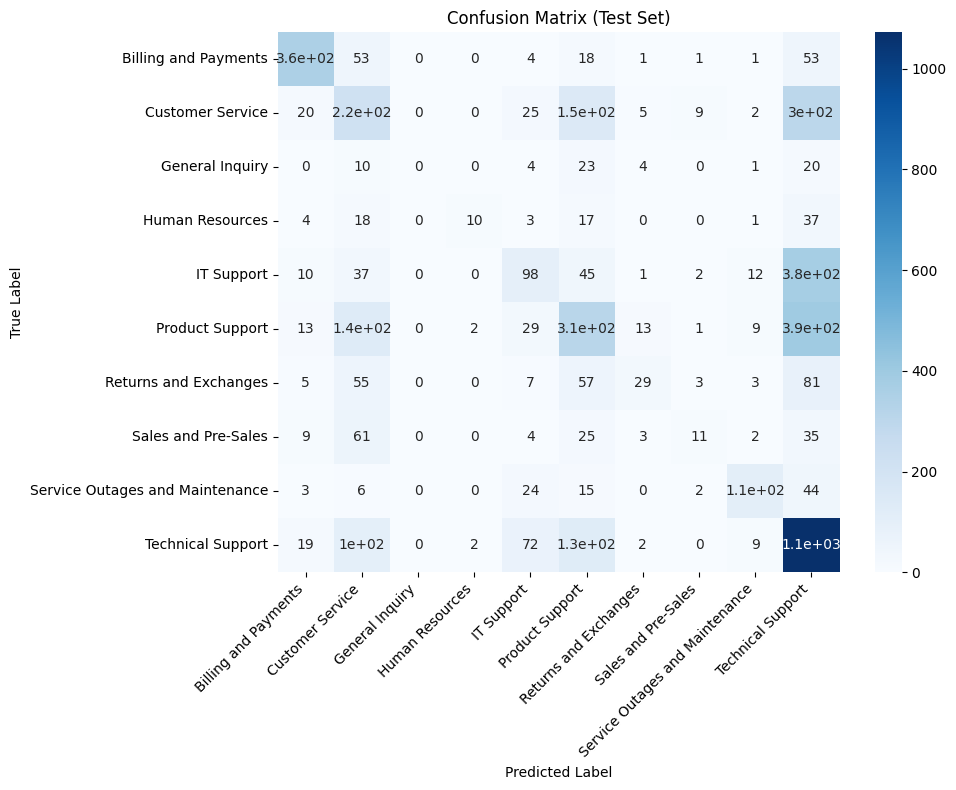

In [19]:
# Generating predictions on the test set and plotting a confusion matrix heatmap.

preds_output = trainer.predict(tokenized["test"])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=-1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_labels)]))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)])
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Inference on New Tickets
Predict the queue for new incoming support tickets

In [20]:
# Defining an inference function and testing predictions on custom ticket text.

def predict_queue(ticket_text: str):
    inputs = tokenizer(ticket_text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))
    return id2label[pred_id], float(probs[pred_id])

samples = [
    "Payment failed twice and my card got charged.",
    "Cannot login to my account after password reset.",
    "Delivery delayed for 5 days, tracking not updating."
]

for s in samples:
    label, confidence = predict_queue(s)
    print(f"TEXT: {s}\nPREDICTED QUEUE: {label} (confidence={confidence:.3f})\n")

TEXT: Payment failed twice and my card got charged.
PREDICTED QUEUE: Billing and Payments (confidence=0.984)

TEXT: Cannot login to my account after password reset.
PREDICTED QUEUE: Product Support (confidence=0.259)

TEXT: Delivery delayed for 5 days, tracking not updating.
PREDICTED QUEUE: Service Outages and Maintenance (confidence=0.475)



## Save the Model
Save fine-tuned model locally (optional)

In [21]:
# Saving the fine-tuned model and tokenizer to disk.

save_path = "./final_ticket_classifier"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./final_ticket_classifier
